# Welcome to PointNet& 3D CNNs Workshop!
In this workshop, we're going to learn how to voxelize a point cloud, and build a 3D Convolutional Neural Network to classify point clouds. When processing point clouds, voxel based approaches account for a good half of the existing approaches (with point based approaches being the second half) — and it's therefore important to understand how to implement them!

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_file_path = '/content/lidar-od-scripts.zip'
extract_dir = 'lidar-od-scripts'

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted '{zip_file_path}' to '{extract_dir}'")

Extracted '/content/lidar-od-scripts.zip' to 'lidar-od-scripts'


In [ ]:
zip_file_path_2 = '/content/shapenet-core-seg.zip'
extract_dir_2 = 'shapenet-core-seg'

# Create the directory if it doesn't exist
os.makedirs(extract_dir_2, exist_ok=True)

with zipfile.ZipFile(zip_file_path_2, 'r') as zip_ref:
        zip_ref.extractall("/content/shapenet-core-seg")

print(f"Extracted '{zip_file_path_2}' to '{extract_dir_2}'")

Extracted '/content/shapenet-core-seg.zip' to 'shapenet-core-seg'


## Imports

In [ ]:
# Usual Imports
import os
import sys
import json
from pathlib import Path
import numpy as np
from tqdm import tqdm

# plotting library
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# append path to custom scripts
sys.path.append('./lidar-od-scripts/gpuVersion/gpuVersion/')

# DL Imports
import torch
import torch.nn as nn

# custom imports
from visual_utils import plot_pc_data3d, plot_bboxes_3d

In [ ]:
# import random
# # 1. Setup paths
# # The path where you put your subset data
# subset_root = "/content/shapenet-core-seg/Shapenetcore_benchmark"
# # The categories you selected (folder names)
# selected_categories = ["02691156", "03642806", "03001627", "03790512", "04225987", "04379243"]
# category_names = ["Airplane", "Chair", "Laptop", "Motorbike", "Skateboard", "Table"]

# train_list = []
# val_list = []
# test_list = []

# # 2. Iterate through each category folder
# for category in category_names:
#     train_files = json.load(open(os.path.join(subset_root, 'train_split.json'), 'r'))
#     train_files = [file for file in train_files if file[1] == category]
#     print(len(train_files))
#     val_files = json.load(open(os.path.join(subset_root, 'val_split.json'), 'r'))
#     val_files = [file for file in val_files if file[1] == category]
#     test_files = json.load(open(os.path.join(subset_root, 'test_split.json'), 'r'))
#     test_files = [file for file in test_files if file[1] == category]
#     indices = np.random.permutation(len(train_files))[:70]
#     train_files = [train_files[i] for i in indices]
#     indices = np.random.permutation(len(val_files))[:10]
#     val_files = [val_files[i] for i in indices]
#     indices = np.random.permutation(len(test_files))[:20]
#     test_files = [test_files[i] for i in indices]

#     train_list.extend(train_files)
#     val_list.extend(val_files)
#     test_list.extend(test_files)

# with open(os.path.join(subset_root, 'train_split.json'), 'w') as f:
#     json.dump(train_list, f)
# with open(os.path.join(subset_root, 'val_split.json'), 'w') as f:
#     json.dump(val_list, f)
# with open(os.path.join(subset_root, 'test_split.json'), 'w') as f:
#     json.dump(test_list, f)

# print(f"Created splits: Train={len(train_list)}, Val={len(val_list)}, Test={len(test_list)}")

1958
2658
324
125
106
3835
Created splits: Train=420, Val=60, Test=120


In [ ]:
DATA_FOLDER = './shapenet-core-seg/Shapenetcore_benchmark/'

class_name_id_map = {'Airplane': 0, 'Bag': 1, 'Cap': 2, 'Car': 3, 'Chair': 4,
                'Earphone': 5, 'Guitar': 6, 'Knife': 7, 'Lamp': 8, 'Laptop': 9,
                'Motorbike': 10, 'Mug': 11, 'Pistol': 12, 'Rocket': 13,
                'Skateboard': 14, 'Table': 15}

class_id_name_map = {v:k for k,v in class_name_id_map.items()}

PCD_SCENE=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False), aspectmode='data')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Shapenet Core Dataset exploration

- Object Classification and part Segmentation Dataset from Point Cloud data
- [Shapenet core](https://shapenet.org/) is a subset of the full ShapeNet dataset
- It contains single clean 3D models, manually verified category and alignment annotations.
- 16 classes from 12 categories

In [ ]:
train_split_data = json.load(open('./shapenet-core-seg/Shapenetcore_benchmark/train_split.json', 'r'))
train_class_count = np.array([x[0] for x in train_split_data])

# plot classwise count in train set
train_dist_plots = [go.Bar(x=list(class_name_id_map.keys()), y= np.bincount(train_class_count))]
layout = dict(template="plotly_dark", title="Shapenet Core Train Distribution", title_x=0.5)
fig = go.Figure(data=train_dist_plots, layout=layout)
fig.show()

In [ ]:
import glob
points_list = glob.glob("./shapenet-core-seg/Shapenetcore_benchmark/04379243/points/*.npy")
print(len(points_list))

5263


In [ ]:
import random
idx = random.randint(0,len(points_list))

# load point cloud data
points = np.load(points_list[idx])
print(f"points shape = {points.shape}, min xyz = {np.min(points, axis=0)}, max xyz = {np.max(points, axis=0)}")

# load segmentation labels
seg_file_path = points_list[idx].replace('points', 'points_label').replace('.npy', '.seg')
seg_labels = np.loadtxt(seg_file_path).astype(np.int8)
print(f"seg_labels shape = {seg_labels.shape}, unique labels = {np.unique(seg_labels)}")

points shape = (2783, 3), min xyz = [-0.3129  -0.2325  -0.31013], max xyz = [0.3129  0.2325  0.31311]
seg_labels shape = (2783,), unique labels = [1 2]


In [ ]:
# there are max of 16 parts in an object in Shapenet core dataset
# creating random colors in according to part label
NUM_PARTS = 16
PART_COLORS = np.random.choice(range(255),size=(NUM_PARTS,3))

In [ ]:
pc_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False, color=PART_COLORS[seg_labels - 1], marker_size=2)
layout = dict(template="plotly_dark", title="Raw Point cloud", scene=PCD_SCENE, title_x=0.5)
fig = go.Figure(data=pc_plots, layout=layout)
fig.show()

## Build a Custom Dataset
Now that we've explored our data, we'll get more 'PyTorch friendly' and create a Dataset object, as well as a PyTorch Dataloader.

In [ ]:
class ShapeNetDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, split_type, num_samples=2500, filtered_class_names=[], max_samples_per_class=np.inf):
        self.root_dir = root_dir
        self.split_type = split_type
        self.num_samples = num_samples
        with open(os.path.join(root_dir, f'{self.split_type}_split.json'), 'r') as f:

            self.split_data = json.load(f)

        # filtering by class names
        filtered_data = []
        class_counts = {}
        for index in range(0, len(self.split_data)):
            # filters only the wanted classes
            cloud_class_name = self.split_data[index][1]
            if cloud_class_name in filtered_class_names:
                # filters only the maximum number of objects allowed
                curr_class_count = class_counts.get(cloud_class_name, 0)
                if curr_class_count <= max_samples_per_class:
                    class_counts[cloud_class_name] = curr_class_count + 1
                    filtered_data.append(self.split_data[index])

        self.split_data = filtered_data


    def __getitem__(self, index):
        # read point cloud data
        class_id, class_name, point_cloud_path, seg_label_path = self.split_data[index]

        # point cloud data
        point_cloud_path = os.path.join(self.root_dir, point_cloud_path)
        pc_data = np.load(point_cloud_path)

        # segmentation labels
        # -1 is to change part values from [1-16] to [0-15]
        # which helps when running segmentation
        pc_seg_labels = np.loadtxt(os.path.join(self.root_dir, seg_label_path)).astype(np.int8) - 1
#         pc_seg_labels = pc_seg_labels.reshape(pc_seg_labels.size,1)

        # Sample fixed number of points
        num_points = pc_data.shape[0]
        if num_points < self.num_samples:
            # Duplicate random points if the number of points is less than max_num_points
            additional_indices = np.random.choice(num_points, self.num_samples - num_points, replace=True)
            pc_data = np.concatenate((pc_data, pc_data[additional_indices]), axis=0)
            pc_seg_labels = np.concatenate((pc_seg_labels, pc_seg_labels[additional_indices]), axis=0)

        else:
            # Randomly sample max_num_points from the available points
            random_indices = np.random.choice(num_points, self.num_samples)
            pc_data = pc_data[random_indices]
            pc_seg_labels = pc_seg_labels[random_indices]

        # return variable
        data_dict= {}
        data_dict['class_id'] = class_id
        data_dict['class_name'] = class_name
        data_dict['points'] = pc_data
        data_dict['seg_labels'] = pc_seg_labels
        return data_dict

    def __len__(self):
        return len(self.split_data)

In [ ]:
filtered_class_names = ["Chair", "Airplane", "Table", "Rocket", "Laptop"]
max_samples_per_class = 100

In [ ]:
train_set = ShapeNetDataset(root_dir = DATA_FOLDER, split_type='train', filtered_class_names=filtered_class_names, max_samples_per_class=max_samples_per_class)
val_set = ShapeNetDataset(root_dir = DATA_FOLDER, split_type='val', filtered_class_names=filtered_class_names, max_samples_per_class=max_samples_per_class)
test_set = ShapeNetDataset(root_dir = DATA_FOLDER, split_type='test', filtered_class_names=filtered_class_names, max_samples_per_class=max_samples_per_class)
print(f"Train set length = {len(train_set)}")
print(f"Validation set length = {len(val_set)}")
print(f"Test set length = {len(test_set)}")

Train set length = 280
Validation set length = 40
Test set length = 80


In [ ]:
data_dict= train_set[25]
print(f"Keys in dataset sample = {list(data_dict.keys())}")
points = data_dict['points']
seg_labels = data_dict['seg_labels']
print(f"class_id = {data_dict['class_id']}, class_name = {data_dict['class_name']}")

Keys in dataset sample = ['class_id', 'class_name', 'points', 'seg_labels']
class_id = 0, class_name = Airplane


In [ ]:
pc_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False, color=PART_COLORS[seg_labels - 1], marker_size=2)
layout = dict(template="plotly_dark", title=f"{data_dict['class_name']}, class id = {data_dict['class_id']}, from Shapenetcore Torch Dataset", scene=PCD_SCENE, title_x=0.5)
fig = go.Figure(data=pc_plots, layout=layout)
fig.show()

### Data loader for Custom dataset

In [ ]:
def collate_fn(batch_list):
    ret = {}
    ret['class_id'] =  torch.from_numpy(np.array([x['class_id'] for x in batch_list])).long()
    ret['class_name'] = np.array([x['class_name'] for x in batch_list])
    ret['points'] = torch.from_numpy(np.stack([x['points'] for x in batch_list], axis=0)).float()
    ret['seg_labels'] = torch.from_numpy(np.stack([x['seg_labels'] for x in batch_list], axis=0)).long()
    return ret

In [ ]:
sample_loader = torch.utils.data.DataLoader(train_set, batch_size=16, num_workers=0, shuffle=True, collate_fn=collate_fn)
dataloader_iter = iter(sample_loader)
batch_dict = next(dataloader_iter)
print(batch_dict.keys())
for key in ['points','seg_labels', 'class_id']:
    print(f"batch_dict[{key}].shape = {batch_dict[key].shape}")

dict_keys(['class_id', 'class_name', 'points', 'seg_labels'])
batch_dict[points].shape = torch.Size([16, 2500, 3])
batch_dict[seg_labels].shape = torch.Size([16, 2500])
batch_dict[class_id].shape = torch.Size([16])


In [ ]:
batchSize= 64
workers = 0
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batchSize, shuffle=True, num_workers=workers, collate_fn=collate_fn)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=batchSize, shuffle=True, num_workers=workers, collate_fn=collate_fn)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batchSize,shuffle=True, num_workers=workers, collate_fn=collate_fn)

# PointNet

**The model is PointNet.**<p>
![PointNet](https://d3i71xaburhd42.cloudfront.net/c3b6a072288e134f5ae6afe3eebc970ffb65cb68/3-Figure2-1.png)

It's coming from the paper: https://arxiv.org/pdf/1612.00593.pdf

The Point-Net will be done in several parts:
* T-Net
* FeatureNet
* Classification or Segmentation Head

### T-Net (`STN3d` class)

The `STN3d` class implements the Spatial Transformer Network (T-Net) for 3D point clouds. Its purpose is to learn a 3x3 affine transformation matrix that aligns the input point cloud to a canonical space. This makes the PointNet robust to various transformations like rotation and translation.

**How it works:**
1.  **Shared MLPs**: It applies a series of 1D convolutional layers (`conv1`, `conv2`, `conv3`) with batch normalization and ReLU activations to the input point features. These convolutions operate independently on each point.
2.  **Max Pooling**: A global max-pooling layer (`mp1`) is used to aggregate the features into a global descriptor.
3.  **Fully Connected Layers**: The global descriptor is then passed through fully connected layers (`fc1`, `fc2`, `fc3`) to predict 9 values, which are then reshaped into a 3x3 matrix.
4.  **Identity Initialization**: The output 3x3 matrix is initialized with an identity matrix. This ensures that in the early stages of training, the transformation is close to identity, preventing drastic initial changes that could destabilize training.

### T-Net

In [ ]:
import torch.nn.functional as F
from torch.autograd import Variable

class STN3d(nn.Module):
    """
    T-Net Model.
    STN stands for Spatial Transformer Network.
    """
    def __init__(self, num_points = 2500):
        super(STN3d, self).__init__()
        self.num_points = num_points
        self.conv1 = torch.nn.Conv1d(3, 64, 1)
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)

        self.mp1 = torch.nn.MaxPool1d(num_points)

        # FC layers
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 9)
        self.relu = nn.ReLU()

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)


    def forward(self, x):
        batchsize = x.size()[0]

        # Expected input shape = (bs, 3, num_points)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.mp1(x)
        x = x.view(-1, 1024)

        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)

        iden = Variable(torch.from_numpy(np.array([1,0,0,0,1,0,0,0,1]).astype(np.float32))).view(1,9).repeat(batchsize,1)
        if x.is_cuda:
            iden = iden.cuda()
        x = x + iden
        x = x.view(-1, 3, 3)
        return x

In [ ]:
test_model = STN3d().to(device)
sim_data = Variable(torch.rand(32,3,2500)).to(device)
out = test_model(sim_data)
print('stn', out.size())

stn torch.Size([32, 3, 3])


## FeatureNet

### FeatureNet (`PointNetfeat` class)

The `PointNetfeat` class is the core feature extraction module of PointNet. It's responsible for transforming the raw point coordinates into meaningful features, either global features for classification or point-wise features for segmentation.

**How it works:**
1.  **Input Transformation**: It first applies the `STN3d` (T-Net) to the input point cloud `x` to get a transformation matrix (`trans`). The input points are then multiplied by this `trans` matrix to align them.
2.  **Shared MLPs (Initial)**: Another set of 1D convolutional layers (`conv1`, `conv2`, `conv3`) with batch normalization and ReLU activations are applied. These MLPs operate on each point independently, increasing the feature dimension.
3.  **Global Max Pooling**: A global max-pooling layer (`mp1`) is applied across all points to extract a single 1024-dimensional **global feature vector**. This vector captures the overall shape information of the point cloud.
4.  **Output Options (`global_feat` parameter)**:
    *   If `global_feat` is `True` (for classification), it returns the 1024-dimensional global feature vector.
    *   If `global_feat` is `False` (for segmentation), it concatenates the global feature vector (repeated for each point) with the *point-wise features* (`pointfeat`) obtained after the first MLP layer (`conv1`). This creates a rich feature vector for each point that combines both global context and local information.

In [ ]:
class PointNetfeat(nn.Module):
    """
    This is the T-Net for Feature Transform.
    There is also MLP part 64,128,1024.
    """
    def __init__(self, num_points = 2500, global_feat = True):
        super(PointNetfeat, self).__init__()
        self.stn = STN3d(num_points = num_points)
        self.conv1 = torch.nn.Conv1d(3, 64, 1)
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.mp1 = torch.nn.MaxPool1d(num_points)
        self.num_points = num_points
        self.global_feat = global_feat

    def forward(self, x):
        batchsize = x.size()[0]
        trans = self.stn(x)
        x = x.transpose(2,1)
        x = torch.bmm(x, trans)
        x = x.transpose(2,1)
        x = F.relu(self.bn1(self.conv1(x)))
        pointfeat = x
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        x = self.mp1(x)
        x = x.view(-1, 1024)
        if self.global_feat:
            return x, trans
        else:
            x = x.view(-1, 1024, 1).repeat(1, 1, self.num_points)
            return torch.cat([x, pointfeat], 1), trans

In [ ]:
pointfeat = PointNetfeat(global_feat=True).to(device)
out, _ = pointfeat(sim_data)
print('global feat', out.size())

pointfeat = PointNetfeat(global_feat=False).to(device)
out, _ = pointfeat(sim_data)
print('point feat', out.size())

global feat torch.Size([32, 1024])
point feat torch.Size([32, 1088, 2500])


### Classifier Head (`PointNetCls` class)

The `PointNetCls` class is the network head used for object classification. It takes the global features extracted by the `PointNetfeat` and processes them to predict the class of the object.

**How it works:**
1.  **Feature Extraction**: It uses the `PointNetfeat` module with `global_feat=True` to obtain the 1024-dimensional global feature vector for the input point cloud.
2.  **Fully Connected Layers**: These global features are then passed through a series of fully connected (dense) layers (`fc1`, `fc2`, `fc3`) with batch normalization and ReLU activations.
3.  **Output**: The final fully connected layer (`fc3`) outputs `k` values, where `k` is the number of classes. A `log_softmax` activation is applied to these outputs to produce log-probabilities for each class, suitable for `NLLLoss`.

## Classifier Head

In [ ]:
class PointNetCls(nn.Module):
    """
    Network for Classification: 512, 256, K.
    """
    def __init__(self, num_points = 2500, k = 2):
        super(PointNetCls, self).__init__()
        self.num_points = num_points
        self.feat = PointNetfeat(num_points, global_feat=True)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
    def forward(self, x):
        x, trans = self.feat(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return F.log_softmax(x, dim=-1), trans

In [ ]:
cls = PointNetCls(k = 16).to(device)
out, _ = cls(sim_data)
print('class', out.size())

class torch.Size([32, 16])


## Training

In [ ]:
def train_model(model, num_epochs, criterion, optimizer, dataloader_train,
                label_str = 'class_id', lr_scheduler = None, output_name = 'pointnet.pth'):
    # move model to device
    model.to(device)

    for epoch in range(num_epochs):
        print(f"Starting {epoch + 1} epoch ...")

        # Training
        model.train()
        train_loss = 0.0
        for batch_dict in tqdm(dataloader_train, total=len(dataloader_train)):
            # Forward pass
            x = batch_dict['points'].transpose(1, 2).to(device)
            labels = batch_dict[label_str].to(device)
            pred, _ = model(x)
            loss = criterion(pred, labels)
            train_loss += loss.item()

            # Backward pass
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # adjust learning rate
            if lr_scheduler is not None:
                lr_scheduler.step()

        # compute per batch losses, metric value
        train_loss = train_loss / len(dataloader_train)

        print(f'Epoch: {epoch+1}, trainLoss:{train_loss:6.5f}')
    torch.save(model.state_dict(), output_name)

In [ ]:
import torch.optim as optim

N_EPOCHS = 10
num_points = 2500
num_classes = 16
criterion = nn.NLLLoss()

# create model, optimizer, lr_scheduler and pass to training function
num_classes = len(class_id_name_map.items())
classifier = PointNetCls(k = num_classes, num_points = num_points)

# DEFINE OPTIMIZERS
optimizer = optim.SGD(classifier.parameters(), lr=0.01, momentum=0.9)
if torch.cuda.is_available():
    classifier.cuda()


_ = train_model(classifier, N_EPOCHS, criterion, optimizer, train_loader)

Starting 1 epoch ...


100%|██████████| 7/7 [01:41<00:00, 14.48s/it]


Epoch: 1, trainLoss:1.23797
Starting 2 epoch ...


100%|██████████| 7/7 [01:39<00:00, 14.17s/it]


Epoch: 2, trainLoss:0.15261
Starting 3 epoch ...


...

Epoch: 8, trainLoss:0.02147
Starting 9 epoch ...


100%|██████████| 7/7 [01:38<00:00, 14.10s/it]


Epoch: 9, trainLoss:0.02218
Starting 10 epoch ...


100%|██████████| 7/7 [01:38<00:00, 14.11s/it]

Epoch: 10, trainLoss:0.01596


## Inference

In [ ]:
classifier = PointNetCls(k=num_classes).to(device)
classifier.load_state_dict(torch.load('pointnet.pth'))
classifier.eval()

total_loss = 0.0

with torch.no_grad():
    for batch_dict in tqdm(test_loader, total=len(test_loader)):
        x = batch_dict['points'].transpose(1, 2).to(device)
        labels = batch_dict['class_id'].to(device)
        pred, _ = classifier(x)

        # calculate loss
        loss = criterion(pred, labels)
        total_loss += loss.item()

evaluation_loss = total_loss / len(test_loader)
print(evaluation_loss)

100%|██████████| 3/3 [00:15<00:00,  5.21s/it]

0.12599373360474905


## Test on individual items

In [ ]:
# Random test sample
test_sample = test_set[np.random.choice(np.arange(len(test_set)))]
batch_dict = collate_fn([test_sample])
x = batch_dict['points'].transpose(1, 2).to(device)

# Get model predictions
model_preds, _ = classifier(x)
predicted_class = torch.argmax(model_preds, axis=1).detach().cpu().numpy()[0]
predicted_class_name = class_id_name_map[predicted_class]
pred_class_probs = F.softmax(model_preds.flatten(), dim=None).detach().cpu().numpy()

# plot results
title = f"Label = {test_sample['class_name']}, Predicted class = {predicted_class_name}"
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scatter3d"}, {}]], column_widths=[0.4, 0.6])
fig.update_layout(template="plotly_dark", scene=PCD_SCENE, height = 400, width = 1200,
                title=title, title_x=0.1, title_y=0.97, margin=dict(r=0, b=0, l=0, t=0))
fig.add_trace(plot_pc_data3d(x=test_sample['points'][:,0], y=test_sample['points'][:,1], z=test_sample['points'][:,2]), row=1, col=1)
fig.add_trace(go.Bar(x=list(class_name_id_map.keys()), y=pred_class_probs, showlegend=False), row=1, col=2)
fig.show()

/tmp/ipython-input-3837583052.py:10: UserWarning:

Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.



### Classifier Head (`PointNetCls` class)

The `PointNetCls` class is the network head used for object classification. It takes the global features extracted by the `PointNetfeat` and processes them to predict the class of the object.

**How it works:**
1.  **Feature Extraction**: It uses the `PointNetfeat` module with `global_feat=True` to obtain the 1024-dimensional global feature vector for the input point cloud.
2.  **Fully Connected Layers**: These global features are then passed through a series of fully connected (dense) layers (`fc1`, `fc2`, `fc3`) with batch normalization and ReLU activations.
3.  **Output**: The final fully connected layer (`fc3`) outputs `k` values, where `k` is the number of classes. A `log_softmax` activation is applied to these outputs to produce log-probabilities for each class, suitable for `NLLLoss`.

## Segmentation (`PointNetDenseCls` class)

The `PointNetDenseCls` class is designed for per-point segmentation. Unlike classification, which uses only global features, segmentation requires predicting a label for *each individual point* in the point cloud. To achieve this, it leverages both local and global features.

**How it works:**
1.  **Point-wise Feature Extraction**: It uses the `PointNetfeat` module with `global_feat=False`. This returns a concatenated feature vector for *each point*, combining the global feature (repeated) and the early point-wise features. This gives each point a rich descriptor that understands both its local geometry and its global context within the object.
2.  **Shared MLPs (Segmentation)**: These concatenated features are then passed through another series of 1D convolutional layers (`conv1`, `conv2`, `conv3`, `conv4`) with batch normalization and ReLU activations. These convolutions operate on the feature vector of each point independently.
3.  **Output**: The final convolutional layer (`conv4`) outputs `k` values for each of the `num_points`. Here, `k` represents the number of possible part labels. The output is a tensor of shape `(batch_size, k, num_points)`, where each `k` dimension represents the score for a specific part label for that point. This output is typically fed into a cross-entropy loss function during training.

## Segmentation

In [ ]:
class PointNetDenseCls(nn.Module):
    """
    Network for Segmentation
    """
    def __init__(self, num_points = 2500, k = 2):
        super(PointNetDenseCls, self).__init__()
        self.num_points = num_points
        self.k = k
        self.feat = PointNetfeat(num_points, global_feat=False)
        self.conv1 = torch.nn.Conv1d(1088, 512, 1)
        self.conv2 = torch.nn.Conv1d(512, 256, 1)
        self.conv3 = torch.nn.Conv1d(256, 128, 1)
        self.conv4 = torch.nn.Conv1d(128, self.k, 1)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)

    def forward(self, x):
        batchsize = x.size()[0]
        x, trans = self.feat(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.conv4(x)
        return x, trans

In [ ]:
seg = PointNetDenseCls(k = 16).to(device)
print(seg)
out, _ = seg(sim_data)
print('seg', out.size())

PointNetDenseCls(
  (feat): PointNetfeat(
    (stn): STN3d(
      (conv1): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (conv3): Conv1d(128, 1024, kernel_size=(1,), stride=(1,))
      (mp1): MaxPool1d(kernel_size=2500, stride=2500, padding=0, dilation=1, ceil_mode=False)
      (fc1): Linear(in_features=1024, out_features=512, bias=True)
      (fc2): Linear(in_features=512, out_features=256, bias=True)
      (fc3): Linear(in_features=256, out_features=9, bias=True)
      (relu): ReLU()
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True

## Training segmentation model

In [ ]:
N_EPOCHS = 10
num_points = 2500
criterion = nn.CrossEntropyLoss()

# create model, optimizer, lr_scheduler and pass to training function
num_classes = len(class_id_name_map.items())
dense_classifier = PointNetDenseCls(k = NUM_PARTS, num_points = num_points)
dense_classifier.to(device)

# DEFINE OPTIMIZERS
optimizer = optim.SGD(dense_classifier.parameters(), lr=0.01, momentum=0.9)

train_model(dense_classifier, N_EPOCHS, criterion, optimizer, train_loader,
            label_str='seg_labels', output_name='pointnet_seg.pth')

Starting 1 epoch ...


100%|██████████| 7/7 [04:01<00:00, 34.44s/it]


Epoch: 1, trainLoss:2.33961
Starting 2 epoch ...


100%|██████████| 7/7 [03:44<00:00, 32.05s/it]


Epoch: 2, trainLoss:1.22121
Starting 3 epoch ...


...

Epoch: 8, trainLoss:0.49141
Starting 9 epoch ...


100%|██████████| 7/7 [03:56<00:00, 33.78s/it]


Epoch: 9, trainLoss:0.46689
Starting 10 epoch ...


100%|██████████| 7/7 [03:43<00:00, 31.98s/it]

Epoch: 10, trainLoss:0.44255


## Inference

In [ ]:
dense_classifier.load_state_dict(torch.load('pointnet_seg.pth'))
dense_classifier.eval()

total_loss = 0.0

with torch.no_grad():
    for batch_dict in tqdm(test_loader, total=len(test_loader)):
        x = batch_dict['points'].transpose(1, 2).to(device)
        labels = batch_dict['seg_labels'].to(device)
        pred, _ = dense_classifier(x)

        # calculate loss
        loss = criterion(pred, labels)
        total_loss += loss.item()

evaluation_loss = total_loss / len(test_loader)
print(evaluation_loss)

100%|██████████| 3/3 [00:31<00:00, 10.53s/it]

0.5382053852081299


## Test on individual items

In [ ]:
# Random test sample
test_sample = test_set[np.random.choice(np.arange(len(test_set)))]
batch_dict = collate_fn([test_sample])

# Get model predictions
x = batch_dict['points'].transpose(1, 2).to(device)
model_preds, _ = dense_classifier(x)
pred_part_labels = torch.argmax(model_preds, axis=1).detach().cpu().numpy()[0]

points = test_sample['points']
part_labels = test_sample['seg_labels']


# plot results
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scatter3d"}, {"type": "scatter3d"}]], column_widths=[0.5, 0.5],
                    subplot_titles=('Part Labels', 'Part Predictions'))

# ground truth part labels
part_label_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False,
                                  color=PART_COLORS[part_labels - 1], marker_size=2)

# ground truth part labels
pred_part_label_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False,
                                  color=PART_COLORS[pred_part_labels - 1], marker_size=2)

fig.update_layout(template="plotly_dark", scene=PCD_SCENE, scene2=PCD_SCENE, height = 400, width = 1200,
                title='PointNet Segmentation', title_x=0.5, title_y=0.97, margin=dict(r=0, b=0, l=0, t=0))
fig.add_trace(part_label_plots, row=1, col=1)
fig.add_trace(pred_part_label_plots, row=1, col=2)
fig.show()

## Task 1: Understand ShapeNet features importance for PointNet  
In this task, we will see how the feature dimensions affect PointNet's performance.

### Defining the projections

In [ ]:
def orthographic_projection(points):
    points_new = points.copy()
    dim = np.random.randint(0, 3) # Pick 0, 1, or 2
    points_new[:, dim] = 0.0
    return points_new

def perspective_projection(points):
    # A. Random Rotation (Euler angles)
    phi, gamma, theta = np.random.uniform(0, 2*np.pi, 3)

    # Rotation Matrices
    Rx = np.array([[1, 0, 0], [0, np.cos(phi), -np.sin(phi)], [0, np.sin(phi), np.cos(phi)]])
    Ry = np.array([[np.cos(gamma), 0, np.sin(gamma)], [0, 1, 0], [-np.sin(gamma), 0, np.cos(gamma)]])
    Rz = np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]])

    # Combined Rotation
    R = Rz @ Ry @ Rx
    rotated_points = points @ R.T
    D = 2.0
    f = 1.0

    x = rotated_points[:, 0]
    y = rotated_points[:, 1]
    z = rotated_points[:, 2]

    factor = f / (z + D + 1e-6)

    x_proj = x * factor
    y_proj = y * factor

    projected_points = np.column_stack((x_proj, y_proj, np.zeros_like(z)))

    return projected_points

### Defining the new dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader
class TransformedDataset(Dataset):
    def __init__(self, original_dataset, transform_func):
        self.dataset = original_dataset
        self.transform_func = transform_func

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Fetch original data
        data = self.dataset[idx]

        # --- FIX: Robust Extraction ---
        if isinstance(data, dict):
            points = data['points']

            # Safe Label Extraction (Avoids '0' being treated as False)
            if 'label' in data:
                label = data['label']
            elif 'class_id' in data:
                label = data['class_id']
            elif 'category' in data:
                label = data['category']
            else:
                print(f"Warning: Label missing at index {idx}. Keys: {data.keys()}")
                label = torch.tensor(0) # Fallback

        else:
            # Tuple case (Standard ShapeNet format is usually points, seg, label)
            points = data[0]
            # Try index 2 (label), fallback to index 1 if len is 2
            if len(data) > 2:
                label = data[2]
            else:
                label = data[1]

        # Ensure points are numpy for transformation
        if isinstance(points, torch.Tensor):
            points = points.cpu().numpy()

        # Apply the specific projection (Orthographic or Perspective)
        points_mod = self.transform_func(points)

        # Return as Float Tensor
        points_tensor = torch.from_numpy(points_mod.astype(np.float32))

        return points_tensor, label

### Training and evaluation

In [ ]:
from torch.utils.data import DataLoader, random_split

def train_and_evaluate(name, transform_func, original_train_set, original_test_set):
    print(f"\n{'='*40}")
    print(f"STARTING EXPERIMENT: {name}")
    print(f"{'='*40}")

    # Create Wrapped Datasets
    train_set_mod = TransformedDataset(original_train_set, transform_func)
    test_set_mod = TransformedDataset(original_test_set, transform_func)

    train_loader = DataLoader(train_set_mod, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_set_mod, batch_size=32, shuffle=False)

    # Model
    model = PointNetCls(k=16)
    if torch.cuda.is_available(): model.cuda()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Train
    epochs = 5
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = 0

        for points, target in train_loader:
            points = points.transpose(2, 1) # (B, 3, N)
            if torch.cuda.is_available():
                points, target = points.cuda(), target.cuda()

            optimizer.zero_grad()
            pred, _ = model(points)

            if target.dim() > 1: target = target[:, 0]
            loss = torch.nn.functional.nll_loss(pred, target.long())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            batch_count += 1

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/batch_count:.4f}")

    # Evaluate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for points, target in test_loader:
            points = points.transpose(2, 1)
            if torch.cuda.is_available():
                points, target = points.cuda(), target.cuda()

            pred, _ = model(points)
            pred_choice = pred.data.max(1)[1]
            if target.dim() > 1: target = target[:, 0]

            correct += pred_choice.eq(target).cpu().sum()
            total += target.size(0)

    acc = correct.item() / float(total) if total > 0 else 0
    print(f"Final Accuracy for {name}: {acc:.4f}")
    return acc

try:
    train_dataset = ShapeNetDataset(root_dir = DATA_FOLDER, split_type='train', filtered_class_names=filtered_class_names, max_samples_per_class=max_samples_per_class)
    test_dataset = ShapeNetDataset(root_dir = DATA_FOLDER, split_type='test', filtered_class_names=filtered_class_names, max_samples_per_class=max_samples_per_class)
    # 1. Run Orthographic Experiment
    acc_ortho = train_and_evaluate("Orthographic (2D Shadow)", orthographic_projection, train_dataset, test_dataset)

    # 2. Run Perspective Experiment
    acc_persp = train_and_evaluate("Perspective (2D Camera)", perspective_projection, train_dataset, test_dataset)

    print("\nSUMMARY:")
    print(f"Orthographic Accuracy: {acc_ortho:.4f}")
    print(f"Perspective Accuracy:  {acc_persp:.4f}")

except NameError:
    print("Error: 'train_dataset' or 'test_dataset' not defined.")
    print("Please make sure you have loaded the datasets in the notebook.")

Train Dataset Size: 419, Test Dataset Size: 151

STARTING EXPERIMENT: Orthographic (2D Shadow)
Epoch 1/5 | Loss: 1.3617
Epoch 2/5 | Loss: 0.4784
Epoch 3/5 | Loss: 0.6074
Epoch 4/5 | Loss: 0.6767
Epoch 5/5 | Loss: 0.4068
Final Accuracy for Orthographic (2D Shadow): 0.8609

STARTING EXPERIMENT: Perspective (2D Camera)
Epoch 1/5 | Loss: 1.9988
Epoch 2/5 | Loss: 1.3194
Epoch 3/5 | Loss: 1.2968
Epoch 4/5 | Loss: 1.1256
Epoch 5/5 | Loss: 1.0857
Final Accuracy for Perspective (2D Camera): 0.3510

SUMMARY:
Orthographic Accuracy: 0.8609
Perspective Accuracy:  0.3510


## Explaining the results:
### Why orthographic worked well
In the Orthographic experiment, we simply dropped one coordinate (e.g., $z=0$). The "shadow" cast is a direct, linear mapping. The relative distances between points in the remaining dimensions ($x, y$) are preserved perfectly. A view from above of an airplane would be more similar to an airplane than a chair. The geometry is simplified, but consistent.
### Why perspective failed
Perspective projection introduces non-linear distortion:

Points closer to the "camera" spread out, while points further away bunch up. When we flatten this to 2D, the density of points changes in complex ways depending on the viewing angle. The model isn't seeing a "3D Point Cloud" anymore; it's seeing a 2D scatter plot that changes wildly with every rotation. To learn this, the model would need to essentially learn "Computer Vision" from scratch.

## Task 2: Understaing PointNet Architecture Modifications
We will change several parameters in the classifier head, and obsever what changes do they cause.

### T-Net

In [ ]:
class STN3d_Modified(nn.Module):
    def __init__(self):
        super(STN3d_Modified, self).__init__()
        # REDUCED DIMENSIONS: 64, 128, 1024 -> 32, 64, 512
        self.conv1 = torch.nn.Conv1d(3, 32, 1)
        self.conv2 = torch.nn.Conv1d(32, 64, 1)
        self.conv3 = torch.nn.Conv1d(64, 512, 1)
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 9)
        self.relu = nn.LeakyReLU(0.01) # CHANGED: ReLU -> LeakyReLU

    def forward(self, x):
        batchsize = x.size()[0]
        x = F.leaky_relu(self.conv1(x), 0.01)
        x = F.leaky_relu(self.conv2(x), 0.01)
        x = F.leaky_relu(self.conv3(x), 0.01)

        # CHANGED: Max Pool -> Average Pool
        x = torch.mean(x, 2, keepdim=True)
        x = x.view(-1, 512)

        x = F.leaky_relu(self.fc1(x), 0.01)
        x = F.leaky_relu(self.fc2(x), 0.01)
        x = self.fc3(x)

        iden = Variable(torch.from_numpy(np.eye(3).flatten().astype(np.float32))).view(1,9).repeat(batchsize,1)
        if x.is_cuda:
            iden = iden.cuda()
        x = x + iden
        x = x.view(-1, 3, 3)
        return x

### FeatureNet



In [ ]:
class PointNetfeat_Modified(nn.Module):
    def __init__(self, global_feat=True, feature_transform=False):
        super(PointNetfeat_Modified, self).__init__()
        self.stn = STN3d_Modified()

        # Reduced dimensions and extra layet
        self.conv1 = torch.nn.Conv1d(3, 32, 1)
        self.conv2 = torch.nn.Conv1d(32, 64, 1)
        self.conv_extra = torch.nn.Conv1d(64, 128, 1) # Extra layer
        self.conv3 = torch.nn.Conv1d(128, 512, 1)     # Reduced final to 512

        self.global_feat = global_feat
        self.feature_transform = feature_transform

    def forward(self, x):
        n_pts = x.size()[2]
        trans = self.stn(x)
        x = x.transpose(2, 1)
        x = torch.bmm(x, trans)
        x = x.transpose(2, 1)

        # ReLU -> LeakyReLU
        x = F.leaky_relu(self.conv1(x), 0.01)
        x = F.leaky_relu(self.conv2(x), 0.01)
        x = F.leaky_relu(self.conv_extra(x), 0.01) # Extra layer
        x = self.conv3(x)

        # Max Pool -> Average Pool
        x = torch.mean(x, 2, keepdim=True)

        x = x.view(-1, 512)
        return x, trans, trans

### Segmentation

In [ ]:
class PointNetCls_Modified(nn.Module):
    def __init__(self, k=2, feature_transform=False):
        super(PointNetCls_Modified, self).__init__()
        self.feature_transform = feature_transform
        self.feat = PointNetfeat_Modified(global_feat=True, feature_transform=feature_transform)

        # Adjusted for 512 input
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, k)
        self.dropout = nn.Dropout(p=0.3)
        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(128)
        self.relu = nn.LeakyReLU(0.01)

    def forward(self, x):
        x, trans, trans_feat = self.feat(x)
        x = F.leaky_relu(self.bn1(self.fc1(x)), 0.01)
        x = F.leaky_relu(self.bn2(self.dropout(self.fc2(x))), 0.01)
        x = self.fc3(x)
        return F.log_softmax(x, dim=1), trans, trans_feat

### Training

In [ ]:
classifier_mod = PointNetCls_Modified(k=15)

if torch.cuda.is_available():
    classifier_mod.cuda()

optimizer = optim.Adam(classifier_mod.parameters(), lr=0.001, betas=(0.9, 0.999))
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

num_epochs = 15
train_loss_hist = []
test_acc_hist = []

print("Start training Modified PointNet...")

for epoch in range(num_epochs):
    classifier_mod.train()
    running_loss = 0.0

    for i, data in enumerate(train_loader, 0):
        points = data['points']
        target = data['seg_labels']
        target = target[:, 0]
        points = points.transpose(2, 1)
        if torch.cuda.is_available():
            points, target = points.cuda(), target.cuda()

        optimizer.zero_grad()
        classifier_mod = classifier_mod.train()
        pred, trans, _ = classifier_mod(points)
        loss = F.nll_loss(pred, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Evaluation per epoch
    classifier_mod.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            points = data['points']
            target = data['seg_labels']
            target = target[:, 0]
            points = points.transpose(2, 1)
            if torch.cuda.is_available():
                points, target = points.cuda(), target.cuda()

            pred, _, _ = classifier_mod(points)
            pred_choice = pred.data.max(1)[1]
            correct += pred_choice.eq(target.data).cpu().sum()
            total += target.size(0)

    test_acc = correct.item() / float(total)
    train_loss_hist.append(running_loss / len(train_loader))
    test_acc_hist.append(test_acc)
    print(f'[Epoch {epoch+1}] Loss: {running_loss / len(train_loader):.4f} Test Acc: {test_acc:.4f}')

torch.save(classifier_mod.state_dict(), 'pointnet_modified.pth')
print("Finished Training Modified Model")

Start training Modified PointNet...


KeyboardInterrupt: 

## T-Net Analysis

Baseline model loaded successfully.


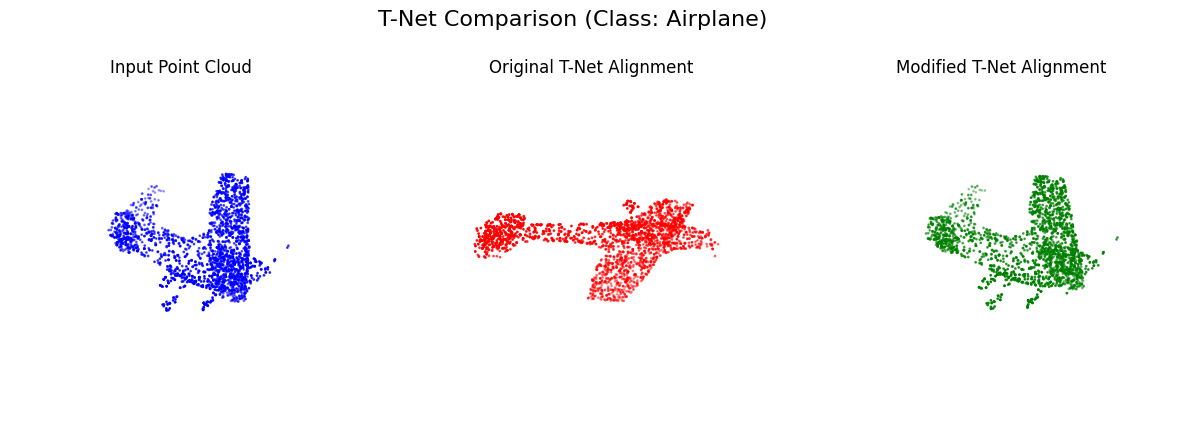

Sample Class: Airplane
Original Matrix (Top Left):
 [[ 2.616025    0.9849722  -0.34131396]
 [-0.74577296  1.1125863  -1.8224483 ]
 [ 0.57213324  0.18607122  0.4846248 ]]
Modified Matrix (Top Left):
 [[ 1.190182    0.06034414  0.011253  ]
 [ 0.03059779  1.5592446   0.10373411]
 [-0.03580449 -0.07193667  1.0234874 ]]


In [ ]:
def visualize_tnet_comparison(orig_model, mod_model, loader):
    orig_model.eval()
    mod_model.eval()

    # 1. Fetch Batch
    batch_data = next(iter(loader))

    # 2. Extract Data using Dictionary Keys
    points = batch_data['points']
    class_names = batch_data['class_name']
    idx = 0
    cls_name = class_names[idx]
    pt = points[idx:idx+1]
    pt_trans = pt.transpose(2, 1)

    if torch.cuda.is_available():
        pt_trans = pt_trans.cuda()

    # 3. Run Models to get T-Net output
    _, trans_orig = orig_model(pt_trans)
    _, trans_mod, _ = mod_model(pt_trans)

    # 4. Apply Matrix Manually for Visualization
    p_cpu = pt.numpy()[0]
    t_orig = trans_orig.cpu().detach().numpy()[0]
    t_mod = trans_mod.cpu().detach().numpy()[0]

    p_orig_aligned = np.matmul(p_cpu, t_orig)
    p_mod_aligned = np.matmul(p_cpu, t_mod)

    # 5. Plot Results
    fig = plt.figure(figsize=(15, 5))
    fig.suptitle(f"T-Net Comparison (Class: {cls_name})", fontsize=16)

    # Plot Input
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    ax1.scatter(p_cpu[:,0], p_cpu[:,1], p_cpu[:,2], c='b', s=1)
    ax1.set_title("Input Point Cloud")
    ax1.set_axis_off()

    # Plot Original T-Net Rotation
    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    ax2.scatter(p_orig_aligned[:,0], p_orig_aligned[:,1], p_orig_aligned[:,2], c='r', s=1)
    ax2.set_title("Original T-Net Alignment")
    ax2.set_axis_off()

    # Plot Modified T-Net Rotation
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    ax3.scatter(p_mod_aligned[:,0], p_mod_aligned[:,1], p_mod_aligned[:,2], c='g', s=1)
    ax3.set_title("Modified T-Net Alignment")
    ax3.set_axis_off()

    plt.show()
    print(f"Sample Class: {cls_name}")
    print("Original Matrix (Top Left):\n", t_orig)
    print("Modified Matrix (Top Left):\n", t_mod)

classifier_orig = PointNetCls(k=16)

try:
    classifier_orig.load_state_dict(torch.load('/content/pointnet.pth'))
    if torch.cuda.is_available():
        classifier_orig.cuda()
    print("Baseline model loaded successfully.")
    visualize_tnet_comparison(classifier_orig, classifier_mod, test_loader)

except FileNotFoundError:
    print("Error: '/content/pointnet.pth' not found.")
except RuntimeError as e:
    print(f"Model mismatch error: {e}")

## Explaining the results:
### Max Pooling -> Average Pooling:
By switching from max pooling to average pooling, we took the average of the data rather than the extreme. This resulted in the shape of the object being blurred and not sharp, making finding the correct rotation harder and less effecient.
### Weaker Architecture:
Our modified architecture has fewer filters (32/64 instead of 64/128). A smaller network is weaker, and might have prioritized learning the features of the object (to get the classification right) rather than learning the alignment (which is a harder geometric task).
### ReLU -> LeakyReLU
We allowed negative values to pass through (slope 0.01) instead of killing them (0).
This prevents "dying neurons" and usually helps gradients flow better.
This might have helped the model converge faster to the "lazy" solution. Because the information flowed easily, the network quickly realized, "I can guess this is a chair without rotating it," and settled into that local minimum before it was forced to learn the harder rotation task.
### Added Extra Layer
We added a conv_extra layer, making the network deeper. On a small dataset (Subset of ShapeNet), deeper networks are harder to train. They require more data to learn effective parameters for every layer.
Combined with the reduced width (fewer neurons), the extra depth likely diluted the gradient signal. By the time the error signal reached the T-Net (which is at the very start of the network), it was too weak to force the T-Net to learn complex rotations.

The T-Net is designed to initialize as an Identity Matrix. This is done so that at the start of training, the network sees the original object, not a distorted mess.

Our Modified model, trained on only 6 classes, could likely already tell these classes apart (e.g., Car vs. Airplane) without rotating since their shapes were different enough. Since it didn't need to rotate the object to minimize the loss, it didn't learn to do so, got a metrix similar to the identity matrix.

The Original Model had a Harder Job:

The Original model was trained on 16 classes (some of which look very similar, like different types of furniture). To tell those apart, it had to learn to rotate them to a standard (canonical) view. That is why the Original alignment looks different—it is actively working to align the object.